# Project 2: Predicting NBA Champions

In this project, I'll be using datasets to predict who will win the next NBA Championship. 
Hopefully through this project I can build a model for all to understand who don't know much about model learning or training.

In [80]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [34]:
# Load in the dataset
df = pd.read_csv(r"/Users/chelseamathelier/ds-studio2/all_season_datenbank.csv")



In [21]:
# Explore the dataset
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   season  1664 non-null   int64  
 1   team    1664 non-null   str    
 2   FG      1663 non-null   float64
 3   FGA     1663 non-null   float64
 4   FG%     1663 non-null   float64
 5   3P      1254 non-null   float64
 6   3PA     1254 non-null   float64
 7   3P%     1254 non-null   float64
 8   2P      1663 non-null   float64
 9   2PA     1663 non-null   float64
 10  2P%     1663 non-null   float64
 11  FT      1663 non-null   float64
 12  FTA     1663 non-null   float64
 13  FT%     1663 non-null   float64
 14  ORB     1373 non-null   float64
 15  DRB     1373 non-null   float64
 16  AST     1663 non-null   float64
 17  STL     1373 non-null   float64
 18  BLK     1373 non-null   float64
 19  TOV     1426 non-null   float64
 20  PF      1663 non-null   float64
 21  PTS     1663 non-null   float64
 22  OFG     142

Index(['season', 'team', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA',
       '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'OFG', 'OFGA', 'OFG%'],
      dtype='str')

In [22]:
# Understanding each feature
df.describe()

,season,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,...,DRB,AST,STL,BLK,TOV,PF,PTS,OFG,OFGA,OFG%
count,1664.000000,1663.000000,1663.000000,1663.000000,1254.000000,1254.000000,1254.000000,1663.000000,1663.000000,1663.000000,...,1373.000000,1663.000000,1373.000000,1373.000000,1426.000000,1663.000000,1663.000000,1424.000000,1424.000000,1424.000000
mean,1993.849159,39.239627,86.779675,0.452408,5.845933,16.544896,0.335667,34.833674,74.303909,0.473949,...,30.822287,23.045039,8.095776,5.028259,15.915428,22.799639,103.133013,39.571067,85.464747,0.462578
std,20.252275,4.374733,7.155057,0.037209,3.814045,10.272500,0.045925,6.351552,15.492906,0.047142,...,2.372507,3.168761,1.133088,0.954231,2.366038,2.716020,9.638244,3.530196,5.542937,0.020107
min,1947.000000,22.400000,70.700000,0.246000,0.100000,0.900000,0.104000,22.400000,41.900000,0.246000,...,24.900000,4.500000,5.500000,2.400000,11.100000,15.600000,60.100000,30.300000,68.800000,0.402000
25%,1980.000000,36.500000,81.600000,0.442000,2.825000,8.425000,0.324000,29.700000,62.000000,0.458000,...,29.100000,21.200000,7.300000,4.400000,14.200000,20.700000,97.300000,36.800000,81.275000,0.450000
50%,1996.500000,39.400000,86.000000,0.458000,5.500000,15.600000,0.348000,32.100000,69.600000,0.480000,...,30.500000,23.200000,8.000000,4.900000,15.300000,22.700000,103.800000,39.600000,85.300000,0.462000
75%,2011.000000,42.500000,90.400000,0.474000,8.100000,22.500000,0.364000,41.250000,86.800000,0.500000,...,32.400000,25.100000,8.800000,5.600000,17.100000,24.800000,110.000000,42.200000,89.300000,0.475000
max,2024.000000,49.900000,119.600000,0.545000,16.700000,45.400000,0.428000,49.900000,119.600000,0.589000,...,42.200000,31.400000,12.900000,8.700000,24.500000,32.100000,126.500000,52.000000,104.300000,0.536000


##  Cleaning Datasets 

So now that we have loaded in our dataset, I'm going to clean everything, eleminate what I believe are unnecessary and start to work towards building visualizations and start to build and train my model.

In [23]:
# cleaning the dataset
# df = df.dropna()
# df = df.drop(columns=['Unnamed: 0','TOV','OTRB'])
rel_cols = ['season', 'team', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%','2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB','AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'OFG', 'OFGA', 'OFG%']
df = df[rel_cols]

In [24]:
df.columns

Index(['season', 'team', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA',
       '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'OFG', 'OFGA', 'OFG%'],
      dtype='str')

In [25]:
# Check if there's null
df.isnull().sum()

season      0
team        0
FG          1
FGA         1
FG%         1
3P        410
3PA       410
3P%       410
2P          1
2PA         1
2P%         1
FT          1
FTA         1
FT%         1
ORB       291
DRB       291
AST         1
STL       291
BLK       291
TOV       238
PF          1
PTS         1
OFG       240
OFGA      240
OFG%      240
dtype: int64

In [26]:
# Check for outliers:
df.describe()

,season,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,...,DRB,AST,STL,BLK,TOV,PF,PTS,OFG,OFGA,OFG%
count,1664.000000,1663.000000,1663.000000,1663.000000,1254.000000,1254.000000,1254.000000,1663.000000,1663.000000,1663.000000,...,1373.000000,1663.000000,1373.000000,1373.000000,1426.000000,1663.000000,1663.000000,1424.000000,1424.000000,1424.000000
mean,1993.849159,39.239627,86.779675,0.452408,5.845933,16.544896,0.335667,34.833674,74.303909,0.473949,...,30.822287,23.045039,8.095776,5.028259,15.915428,22.799639,103.133013,39.571067,85.464747,0.462578
std,20.252275,4.374733,7.155057,0.037209,3.814045,10.272500,0.045925,6.351552,15.492906,0.047142,...,2.372507,3.168761,1.133088,0.954231,2.366038,2.716020,9.638244,3.530196,5.542937,0.020107
min,1947.000000,22.400000,70.700000,0.246000,0.100000,0.900000,0.104000,22.400000,41.900000,0.246000,...,24.900000,4.500000,5.500000,2.400000,11.100000,15.600000,60.100000,30.300000,68.800000,0.402000
25%,1980.000000,36.500000,81.600000,0.442000,2.825000,8.425000,0.324000,29.700000,62.000000,0.458000,...,29.100000,21.200000,7.300000,4.400000,14.200000,20.700000,97.300000,36.800000,81.275000,0.450000
50%,1996.500000,39.400000,86.000000,0.458000,5.500000,15.600000,0.348000,32.100000,69.600000,0.480000,...,30.500000,23.200000,8.000000,4.900000,15.300000,22.700000,103.800000,39.600000,85.300000,0.462000
75%,2011.000000,42.500000,90.400000,0.474000,8.100000,22.500000,0.364000,41.250000,86.800000,0.500000,...,32.400000,25.100000,8.800000,5.600000,17.100000,24.800000,110.000000,42.200000,89.300000,0.475000
max,2024.000000,49.900000,119.600000,0.545000,16.700000,45.400000,0.428000,49.900000,119.600000,0.589000,...,42.200000,31.400000,12.900000,8.700000,24.500000,32.100000,126.500000,52.000000,104.300000,0.536000


In [27]:
df.head()

,season,team,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,...,DRB,AST,STL,BLK,TOV,PF,PTS,OFG,OFGA,OFG%
0,2024,Indiana Pacers,47.0,92.7,0.507,13.2,35.3,0.374,33.8,57.4,...,31.4,30.8,7.7,5.9,12.9,21.4,123.3,44.5,89.8,0.496
1,2024,Boston Celtics,43.9,90.2,0.487,16.5,42.5,0.388,27.4,47.7,...,35.6,26.9,6.8,6.6,11.9,16.2,120.6,41.5,91.6,0.453
2,2024,Oklahoma City Thunder,44.5,89.3,0.499,13.3,34.2,0.389,31.3,55.1,...,33.2,27.1,8.5,6.6,12.7,18.8,120.1,40.6,89.3,0.455
3,2024,Milwaukee Bucks,43.1,88.5,0.487,14.2,38.1,0.373,29.0,50.4,...,34.8,26.5,6.8,5.0,12.9,19.2,119.0,43.2,91.9,0.470
4,2024,Atlanta Hawks,43.0,92.5,0.465,13.7,37.7,0.364,29.3,54.8,...,32.2,26.6,7.5,4.5,13.5,18.6,118.3,44.6,90.2,0.495


In [28]:
df.to_csv('cleaned_nba_stats.csv', index=False)

In [29]:
df = pd.read_csv('/Users/chelseamathelier/ds-studio2/cleaned_nba_stats.csv')

In [35]:
df.columns

Index(['Unnamed: 0', 'season', 'team', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%',
       '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'OFG', 'OFGA', 'OFG%', 'O3P', 'O3PA',
       'O3P%', 'O2P', 'O2PA', 'O2P%', 'OFT', 'OFTA', 'OFT%', 'OORB', 'ODRB',
       'OTRB', 'OAST', 'OSTL', 'OBLK', 'OTOV', 'OPF', 'OPTS', 'champion'],
      dtype='str')

So now that I've cleaned and checked if there's any null or outliers, it's time to start building predictions and visualization. I also had to manually add the champion column due to the null information from Kaggle.

## Data Analysis

In [75]:
# Observe Distribution of X and Y variable
X = df.drop(columns=["champion", "team", "season"])
y = df["champion"]


In [54]:
# Target
y = df["champion"]

# Features
X = df.drop(columns=["champion", "team", "season", "Unnamed: 0"])

In [55]:
df["champion"].value_counts()

Series([], Name: count, dtype: int64)

Even after manually adding the results of the champions it still said null, so now I'm going to manually add the champions through coding.

In [57]:
champions = {
    2010: "Lakers",
    2011: "Mavericks",
    2012: "Heat",
    2013: "Heat",
    2014: "Spurs",
    2015: "Warriors",
    2016: "Cavaliers",
    2017: "Warriors",
    2018: "Warriors",
    2019: "Raptors",
    2020: "Lakers",
    2021: "Bucks",
    2022: "Warriors",
    2023: "Nuggets",
    2024: "Celtics"
}

df["champion"] = df.apply(
    lambda row: 1 if champions.get(row["season"]) == row["team"] else 0,
    axis=1
)

In [58]:
df["champion"].value_counts()

champion
0    1664
Name: count, dtype: int64

In [59]:
df["team"].unique()
df["season"].unique()

array([2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014,
       2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003,
       2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992,
       1991, 1990, 1989, 1988, 1987, 1986, 1985, 1984, 1983, 1982, 1981,
       1980, 1979, 1978, 1977, 1976, 1975, 1974, 1973, 1972, 1971, 1970,
       1969, 1968, 1967, 1966, 1965, 1964, 1963, 1962, 1961, 1960, 1959,
       1958, 1957, 1956, 1955, 1954, 1953, 1952, 1951, 1950, 1949, 1948,
       1947])

In [60]:
df["team"].unique()

<StringArray>
[                   'Indiana Pacers',                    'Boston Celtics',
             'Oklahoma City Thunder',                   'Milwaukee Bucks',
                     'Atlanta Hawks',                'Los Angeles Lakers',
                  'Dallas Mavericks',             'Golden State Warriors',
                  'Sacramento Kings',                      'Phoenix Suns',
                         'Utah Jazz',              'Los Angeles Clippers',
              'New Orleans Pelicans',                    'Denver Nuggets',
                'Philadelphia 76ers',                   'Houston Rockets',
                'Washington Wizards',            'Minnesota Timberwolves',
                   'New York Knicks',               'Cleveland Cavaliers',
                   'Toronto Raptors',                     'Chicago Bulls',
                 'San Antonio Spurs',                     'Orlando Magic',
                     'Brooklyn Nets',                        'Miami Heat',
           

In [61]:
champions = {
    2010: "Los Angeles Lakers",
    2011: "Dallas Mavericks",
    2012: "Miami Heat",
    2013: "Miami Heat",
    2014: "San Antonio Spurs",
    2015: "Golden State Warriors",
    2016: "Cleveland Cavaliers",
    2017: "Golden State Warriors",
    2018: "Golden State Warriors",
    2019: "Toronto Raptors",
    2020: "Los Angeles Lakers",
    2021: "Milwaukee Bucks",
    2022: "Golden State Warriors",
    2023: "Denver Nuggets",
    2024: "Boston Celtics"
}

In [62]:
df["champion"] = df.apply(
    lambda row: 1 if champions.get(row["season"]) == row["team"] else 0,
    axis=1
)

In [63]:
df["champion"].value_counts()

champion
0    1649
1      15
Name: count, dtype: int64

In [65]:
df["champion"] = df["champion"].fillna(0).astype(int)

In [66]:
df["champion"].value_counts()

champion
0    1649
1      15
Name: count, dtype: int64

In [70]:
df["champion"] = df["champion"].fillna(0).astype(int)

In [74]:
df.isnull().sum()

Unnamed: 0    0
season        0
team          0
FG            0
FGA           0
FG%           0
3P            0
3PA           0
3P%           0
2P            0
2PA           0
2P%           0
FT            0
FTA           0
FT%           0
ORB           0
DRB           0
TRB           0
AST           0
STL           0
BLK           0
TOV           0
PF            0
PTS           0
OFG           0
OFGA          0
OFG%          0
O3P           0
O3PA          0
O3P%          0
O2P           0
O2PA          0
O2P%          0
OFT           0
OFTA          0
OFT%          0
OORB          0
ODRB          0
OTRB          0
OAST          0
OSTL          0
OBLK          0
OTOV          0
OPF           0
OPTS          0
champion      0
dtype: int64

In [73]:
df = df.dropna()

## Modeling Attempts

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [77]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (1003, 43)
X_test (251, 43)
y_train (1003,)
y_test (251,)


In [81]:
dt_model = DecisionTreeClassifier()
dt_model = dt_model.fit(X_train,y_train)

In [82]:
accuracy = dt_model.score(X_test, y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9721115537848606


Decision Tree and Barplot time!

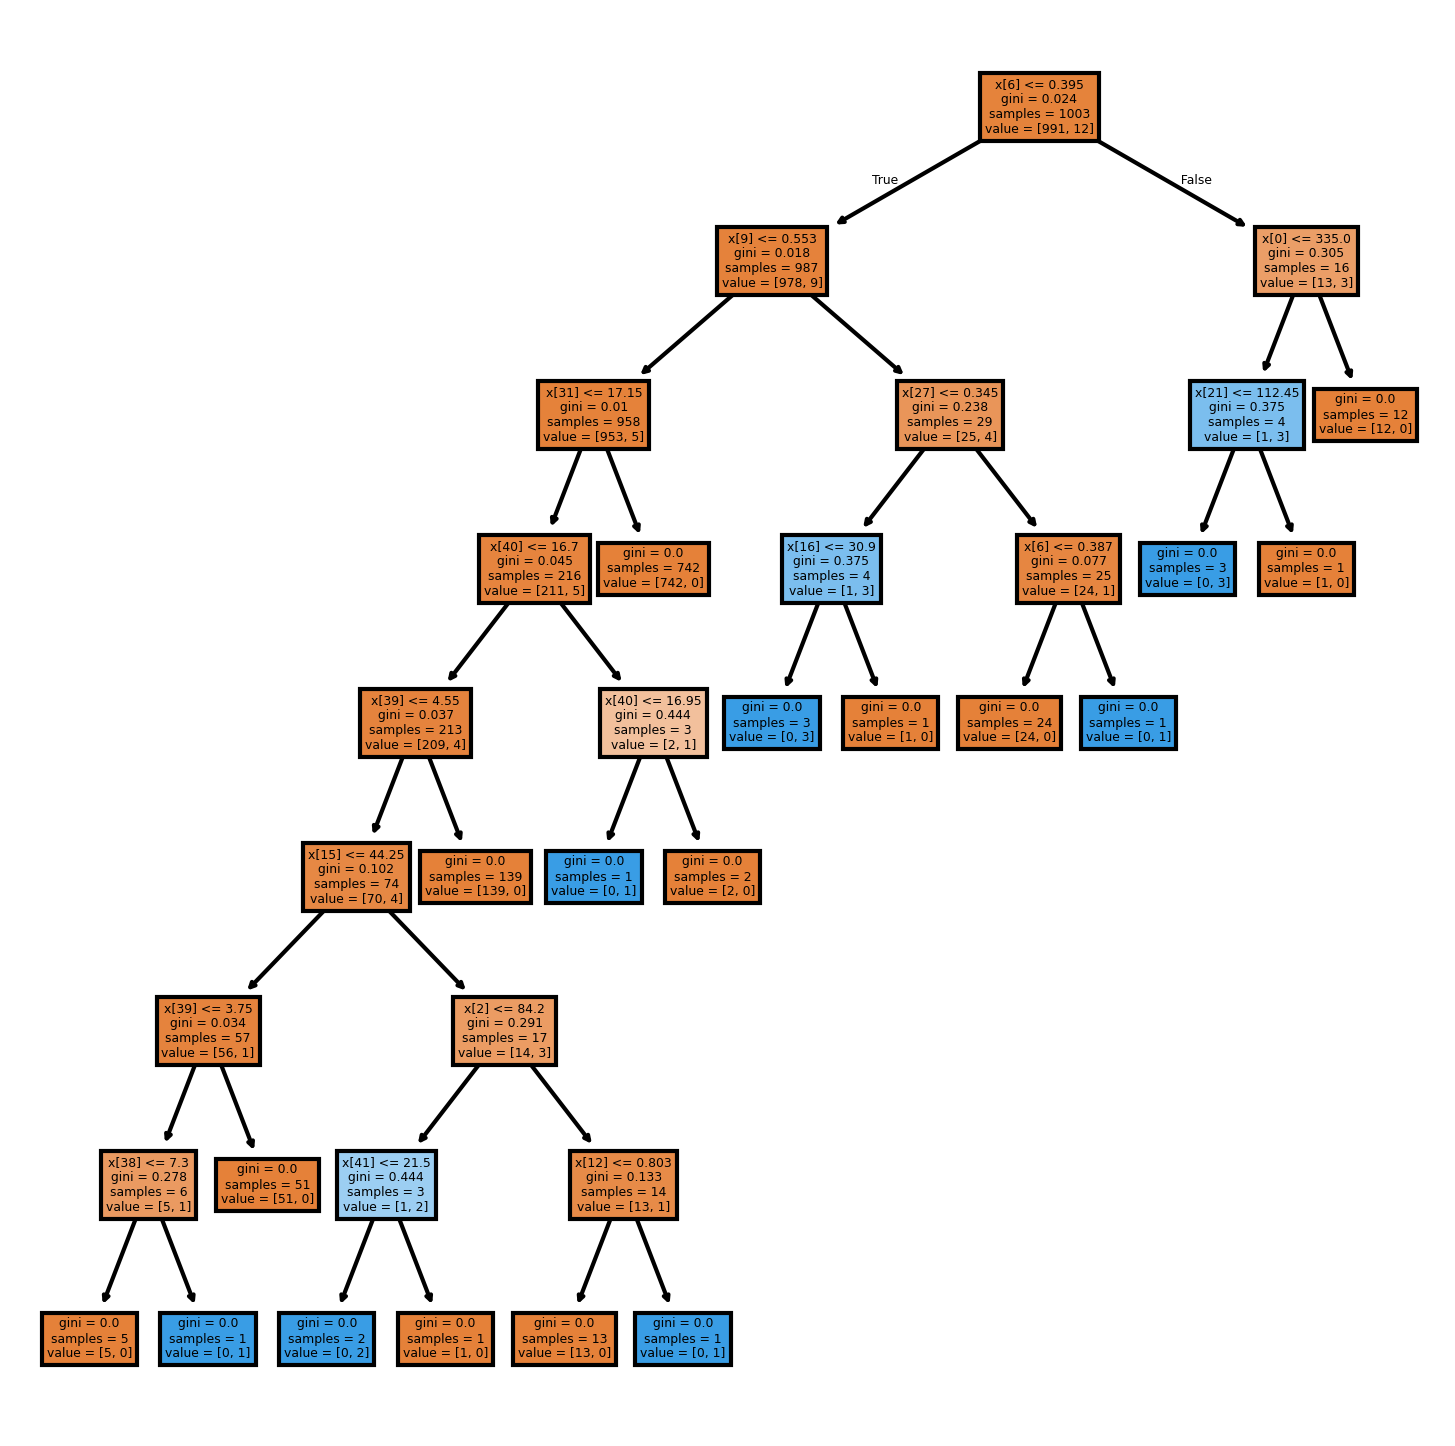

In [84]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)
tree.plot_tree(dt_model, filled=True)
plt.show()

/var/folders/xh/5rbkw_zs7_30s2jnzbhxzy2h0000gn/T/ipykernel_50869/2630536156.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


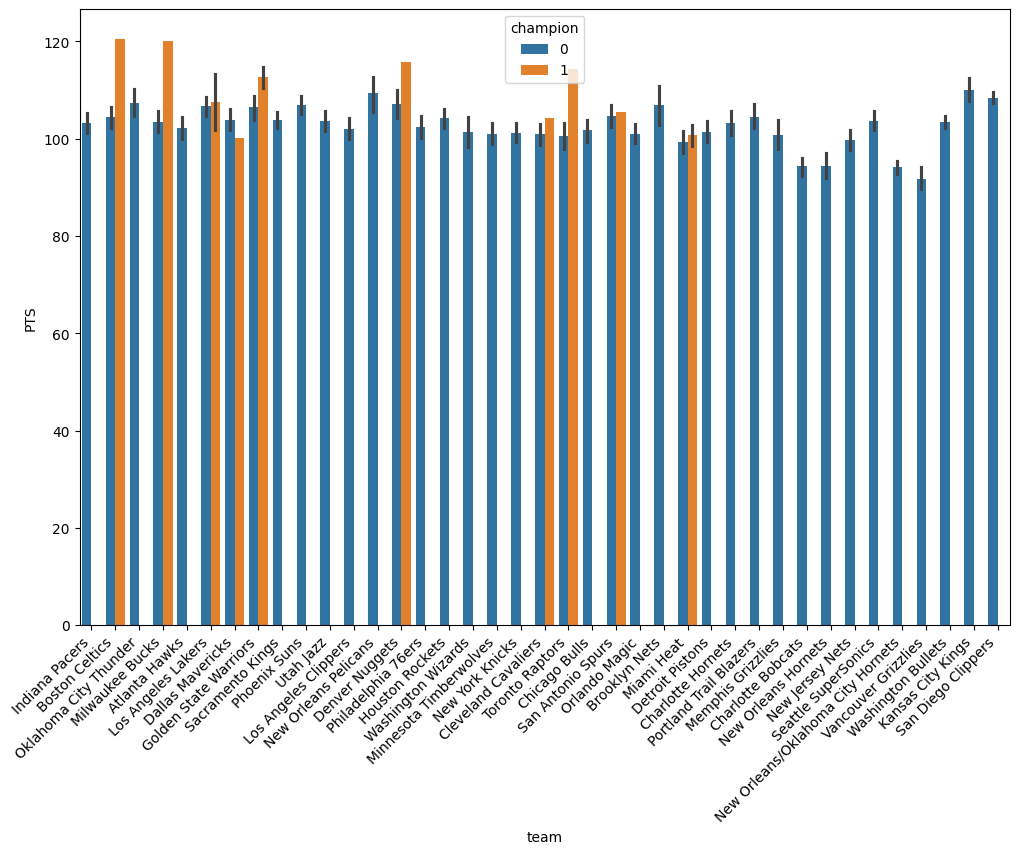

In [85]:
plt.figure(figsize=(12, 8))
chart = sns.barplot(x=df["team"], y=df["PTS"], hue=df["champion"])
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()



## Cross Validation

In [87]:
scores = cross_val_score(dt_model, X, y, cv=5, scoring='recall')

In [88]:
print("Cross-validated recall scores:", scores)
print("Average cross-validated recall score:", scores.mean())

Cross-validated recall scores: [1.         0.         0.66666667 0.         0.        ]
Average cross-validated recall score: 0.3333333333333333


My recall score here is between 0 and 1 because my model has very few postive seasons to work with. This leads to false accuracy and it causes my model to fail identifying champions.

## Evaluation

In [90]:
fi = dt_model.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending

/var/folders/xh/5rbkw_zs7_30s2jnzbhxzy2h0000gn/T/ipykernel_50869/3336114049.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


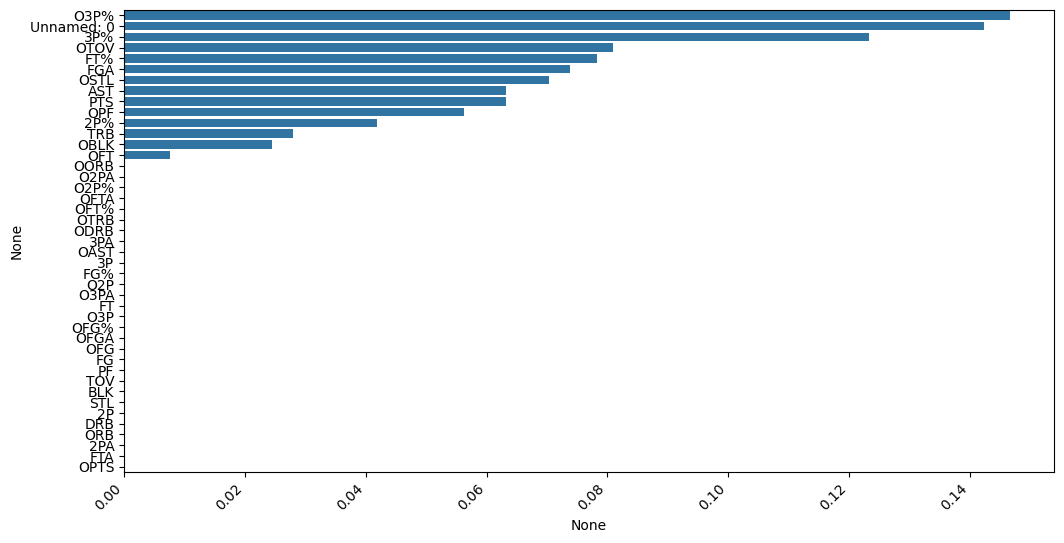

In [91]:
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

## Precision and F1 (Experiments)

In [95]:
y_pred = dt_model.predict(X_test)

In [93]:
confusion_matrix(y_test, dt_model.predict(X_test))

array([[242,   6],
       [  1,   2]])

In [96]:
precision_score(y_test, y_pred)

0.25

In [97]:
f1_score(y_test, y_pred)

0.36363636363636365

So to conclude, I have low outcomes with precision and recall which means theres errors within my model which isn't surpising because of how much I manually added and changed.